In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data.create_dataset import create_dataset, process_dataset, POLICY_COLS

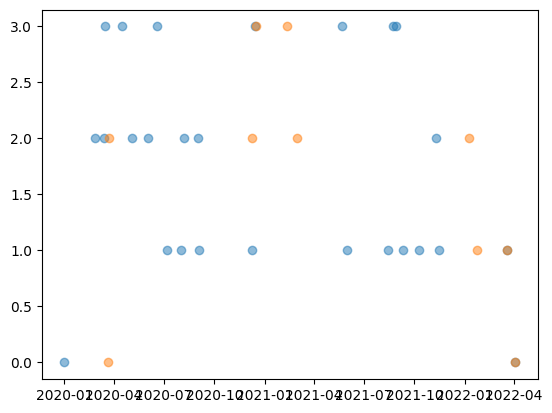

Bad pipe message: %s [b';Cckj~\xa0\xd9\xa559\x90#\xf7\x1c\x12\xfaM\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02', b'\x13\x04\x13\x05\xc0\x01\xc0\x02\xc0\x03\xc0\x04\xc0\x05\xc0\x06\xc0\x07', b"\xc0\t\xc0\n\xc0\x0b\xc0\x0c\xc0\r\xc0\x0e\xc0\x0f\xc0\x10\xc0\x11\xc0\x12\xc0\x13\xc0\x14\xc0\x15\xc0\x16\xc0\x17\xc0\x18\xc0\x19\xc0#\xc0$\xc0%\xc0&\xc0'\xc0(\xc0)\

In [31]:
school = process_dataset(pd.read_csv("data/germany-dataset.csv"), "C1E_School closing", True)
work = process_dataset(pd.read_csv("data/germany-dataset.csv"), "C2E_Workplace closing", True)
plt.scatter(school["Date"], school["Score"], alpha=0.5)
plt.scatter(work["Date"], work["Score"], alpha=0.5)
plt.show()

In [2]:
aus = create_dataset(
    ["data/raw/OxCGRT_raw_AUS_v1.csv"],
    {"RegionName": "New South Wales"},
    POLICY_COLS
)
print(len(aus))
aus = aus[aus["Jurisdiction"] == "STATE_GOV"]
print(len(aus))
aus = aus[~aus["C1_Source"].isna()]
print(len(aus))
for _, row in aus.iterrows():
    print(row["Date"].date(), row["C1E_School closing"], row["C1E_Flag"], row["C1_Source"], row["C1_Notes"])

590
224
115
2020-01-21 0.0 nan https://web.archive.org/web/20200222022137/https://www.health.nsw.gov.au/news/Pages/20200121_00.aspx There were no official public health measures imposed on schools.  The first NSW Health media release addressing COVID-19 was published on 21 January 2020.  According to this media release, no cases of COVID-19 had been detected in NSW.   The Director of Health Protection stated that:  “There is no need for alarm, but people should be aware of the emerging situation and if they develop symptoms on returning from affected areas overseas, they should call ahead before seeing their GP"  He also encouraged individuals with COVID-19 symptoms to practice simple hygiene measures such as hand-washing and covering coughs and sneezes.  https://web.archive.org/web/20200222022137/https://www.health.nsw.gov.au/news/Pages/20200121_00.aspx
2020-02-01 0.0 nan https://web.archive.org/web/20200314093524/https://education.nsw.gov.au/public-schools/school-safety/novel-coronav

/Users/964840/workspace/neuro-san-prana/data/create_dataset.py:65: DtypeWarning: Columns (4,5,67,69,78,98,116) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))


43


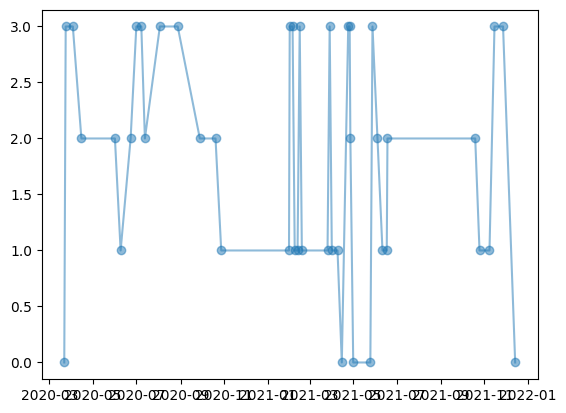

In [ ]:
df = pd.read_csv("data/germany-dataset.csv")
processed = process_dataset(df, "C1E_School closing", True)
print(len(processed))
plt.plot(processed["Date"], processed["Score"], marker="o", alpha=0.5)
plt.show()

In [18]:
policy = "C1E_School closing"
df["Date"] = pd.to_datetime(df["Date"])
source_col = f"{policy[:2]}_Source"
df = df.dropna(subset=[source_col])
df = df.sort_values(by=["Date"])
forward = df[policy].shift(1).fillna(0)
back = df[policy].shift(-1).fillna(0)
df = df[(df[policy] != forward) | (df[policy] != back)]
region_col = "CountryName" if df["RegionName"].isna().all() else "RegionName"
# df = df[["Date", region_col, policy, source_col]]
# df = df.rename(columns={region_col: "Region", policy: "Score", source_col: "Source"})
df["Policy"] = policy

In [21]:
df[["Date", policy, "C1_Notes"]]

,Date,C1E_School closing,C1_Notes
13,2020-03-22,0.0,"Prime Minister says schools remain open, but p..."
15,2020-03-24,3.0,School holidays will be brought forward to thi...
22,2020-04-03,3.0,The Federal Education Minister of Australia ha...
24,2020-04-15,2.0,Throughout March the Morrison government oppos...
33,2020-06-01,2.0,All students in the ACT had returned to school...
34,2020-06-09,1.0,The return to school of specific year groups i...
36,2020-06-23,2.0,"Due to a cluster of COVID virus in Victoria, t..."
38,2020-07-01,3.0,9 postcodes within the state of Victoria have ...
39,2020-07-08,3.0,Schools in Melbourne and an area to the north ...
40,2020-07-13,2.0,"Schools in regional and rural Victoria, other ..."


In [38]:
LOG_DIR = "logs/germany-summarizer"
DATASET_PATH = "data/germany-dataset.csv"
POLICY = "C1E_School closing"

In [ ]:
def compute_metrics(results_dir: str, label_path: str, policy: str, shorten: bool = False):
    labels = pd.read_csv(label_path)
    labels = process_dataset(labels, policy, shorten)

    preds = pd.read_csv(results_dir)
    preds["Date"] = pd.to_datetime(preds["Date"])
    preds = preds.sort_values(by="Date")

    preds["Score"] = preds["Score"].fillna("0")
    preds["Score"] = preds["Score"].astype(str)
    valid_scores = ["0", "1", "2", "3"]
    # any score not in valid scores should be set to 0
    preds["Score"] = preds["Score"].apply(lambda x: x if x in valid_scores else "0")
    preds["Score"] = preds["Score"].astype(int)

    merged = pd.merge(labels, preds, on="Date", suffixes=("", "_Pred"), how="left")
    merged["Score_Pred"] = merged["Score_Pred"].fillna(0)

    error = np.abs(merged["Score"] - merged["Score_Pred"])
    mae = error.mean()
    print(f"Mean Absolute Error: {mae}")

    accuracy = (merged["Score"] == merged["Score_Pred"]).mean()
    print(f"Accuracy: {accuracy}")

compute_metrics(LOG_DIR + "/persistence.csv", DATASET_PATH, POLICY, True)

Mean Absolute Error: 0.5769230769230769


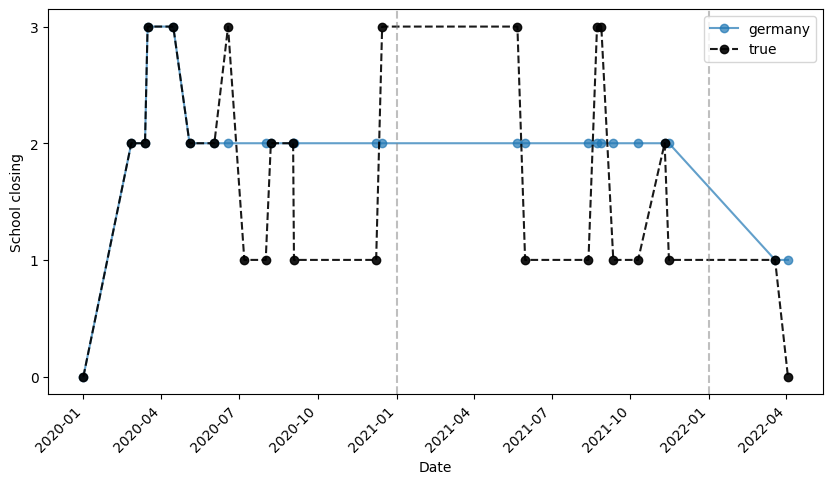

In [40]:
def compare_results(results_dirs: dict[str, str], label_path: str, policy: str, shorten: bool = False, show_cases: bool = False):

    fig, ax = plt.subplots(figsize=(10, 5))

    labels = pd.read_csv(label_path)
    labels = process_dataset(labels, policy, shorten)

    for label, path in results_dirs.items():
        preds = pd.read_csv(path)
        preds["Date"] = pd.to_datetime(preds["Date"])
        preds = preds.sort_values(by="Date")

        preds["Score"] = preds["Score"].fillna("0")
        preds["Score"] = preds["Score"].astype(str)
        valid_scores = ["0", "1", "2", "3"]
        # any score not in valid scores should be set to 0
        preds["Score"] = preds["Score"].apply(lambda x: x if x in valid_scores else "0")
        preds["Score"] = preds["Score"].astype(int)

        merged = pd.merge(labels, preds, on="Date", suffixes=("", "_Pred"), how="left")
        merged["Score_Pred"] = merged["Score_Pred"].fillna(0)

        ax.plot(preds["Date"], preds["Score"], marker="o", alpha=0.7, label=label)

    ax.plot(labels["Date"], labels["Score"], marker="o", color="black", alpha=0.9, linestyle="--", label="true")

    ax.axvline(pd.to_datetime("2021-01-01"), color="gray", linestyle="--", alpha=0.5)
    ax.axvline(pd.to_datetime("2022-01-01"), color="gray", linestyle="--", alpha=0.5)

    ax.legend()
    ax.set_xlabel("Date")
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel("School closing")

    # Plot cases on secondary axis
    if show_cases:
        ax2 = ax.twinx()
        ax2.set_ylabel("Cases")
        ax2.plot(labels["Date"], labels["ConfirmedCases"], color="red", marker="o", label="Cases")

    plt.show()

compare_results(
    {"germany": LOG_DIR + "/persistence.csv"},
     DATASET_PATH,
     POLICY,
     True
)

0.046116549210788865
0.19375


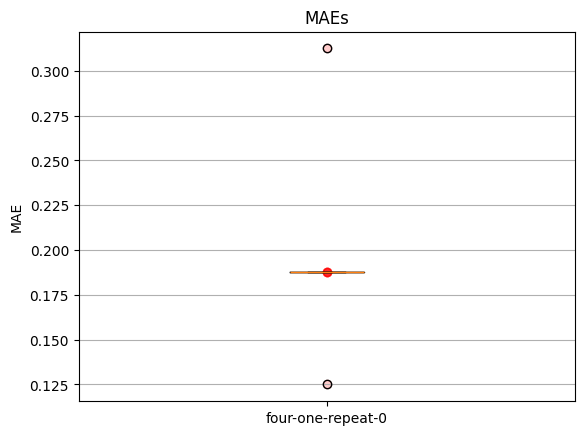

In [7]:
def compare_repeats(all_results_paths: list[list[str]], label_path: str):
    labels = pd.read_csv(label_path)
    labels["Date"] = pd.to_datetime(labels["Date"])


    fig, ax = plt.subplots()
    for i, results_paths in enumerate(all_results_paths):

        errors = []
        for results_path in results_paths:
            preds = pd.read_csv(results_path)
            preds["Date"] = pd.to_datetime(preds["Date"])
            valid_scores = ["0", "1", "2", "3"]
            preds["Score"] = preds["Score"].astype(str).apply(lambda x: x if x in valid_scores else "0")
            preds["Score"] = preds["Score"].astype(int)

            merged = labels.merge(preds, on="Date", how="left", suffixes=("", "_Pred")).copy()
            merged["Score_Pred"] = merged["Score_Pred"].fillna(0)
            error = merged["Score_Pred"] - merged["Score"]
            mae = error.abs().mean()
            errors.append(mae)
        
        stdev = pd.Series(errors).std()
        print(stdev)
        mean = pd.Series(errors).mean()
        print(mean)

        ax.boxplot(errors, positions=[i+1])
        ax.scatter([i+1] * len(errors), errors, color="red", alpha=0.2)

    ax.set_title("MAEs")
    ax.set_ylabel("MAE")
    x_names = [r[0].split("/")[-2] for r in all_results_paths]
    ax.set_xticks(range(1, len(x_names)+1), x_names)
    ax.grid(axis="y")

    plt.show()

# repeats = [
#     [f"../logs/mini-repeat-{i}/persistence.csv" for i in range(10)],
#     [f"../logs/mini-historian-repeat-{i}/persistence.csv" for i in range(5)],
# ]

repeats = [[f"logs/four-one-repeat-{i}/persistence.csv" for i in range(10)]]

compare_repeats(repeats, "data/england-dataset.csv")

In [41]:
def question_average_correctness(results_paths: list[str], label_path: str):
    labels = pd.read_csv(label_path)
    labels["Date"] = pd.to_datetime(labels["Date"])

    all_errors = []
    for path in results_paths:
        preds = pd.read_csv(path)
        preds["Date"] = pd.to_datetime(preds["Date"])
        preds["Score"] = preds["Score"].astype(str).apply(lambda x: x if x in ["0", "1", "2", "3"] else "0")
        preds["Score"] = preds["Score"].astype(int)

        merged = labels.merge(preds, on="Date", how="left", suffixes=("", "_Pred")).copy()
        merged["Score_Pred"] = merged["Score_Pred"].fillna(0)
        error = merged["Score_Pred"] - merged["Score"]
        all_errors.append(error.to_list())

    all_errors = np.array(all_errors)
    mean_question_errors = np.mean(all_errors, axis=0)

    fig, ax = plt.subplots()
    ax.bar(range(len(mean_question_errors)), mean_question_errors)
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean Error Across Trials")
    ax.axhline(0, color="black")
    ax.set_xticks(range(len(mean_question_errors)), labels["Date"].apply(lambda x: x.date()), rotation=90)
    plt.show()

question_average_correctness(repeats[0], "data/england-dataset.csv")

NameError: name 'repeats' is not defined

In [42]:
def get_wrong_with_notes(results_path: str, label_path: str, shorten: bool = False):
    preds = pd.read_csv(results_path)
    print(preds.columns)
    labels = pd.read_csv(label_path)
    labels = process_dataset(labels, "C1E_School closing", shorten=shorten)
    print(labels.columns)

    labels["Date"] = pd.to_datetime(labels["Date"])
    preds["Date"] = pd.to_datetime(preds["Date"])

    labels = labels.merge(preds[["Date", "Score", "Notes"]], on="Date", how="left", suffixes=("", "_Pred"))

    wrong = labels[labels["Score"] != labels["Score_Pred"]]
    for _, row in wrong.iterrows():
        print(row["Date"].date(), row["Score_Pred"], "-", int(row["Score"]))
        print("\t", row["Notes_Pred"])
        print("\t", row["Notes"])

get_wrong_with_notes(LOG_DIR + "/persistence.csv", DATASET_PATH, True)

Index(['Date', 'Region', 'Policy', 'Score', 'Notes'], dtype='object')
Index(['Date', 'Region', 'Score', 'Source', 'Notes', 'Policy'], dtype='object')
2020-06-18 2.0 - 3
	 On 2020-06-18, all schools in the Gütersloh district were ordered to close for general classroom instruction, with only emergency childcare provided, in response to a localized COVID-19 outbreak (per the official district press release). Per OxCGRT guidelines, this is a required closing for some levels/categories (targeted, not national), matching score 2. National policy overall remained at partial openings; prior history supports this as a targeted, not general, closure.
	 Due to a local outbreak of Corona in a meat-processing factory "Tönnies", the district around "Gütersloh" underlies stricter Corona measures.  As this relapse seems relevant (and follows the general strategy of the federal government to impose locally stricter rules), the entries in the database reflect the stricter situation in "Gütersloh" with t

In [10]:
def check_validator_necessary(log_path: str):
    n_fails = 0
    with open(log_path, "r", encoding="utf-8") as f:
        content = f.read()
        n_fails += content.count("Needs Revision")
    print(n_fails)
    return n_fails

log_paths = [f"logs/four-one-repeat-{i}/news_analyst.validator_coordinator" for i in range(10)]
n_fails = sum(check_validator_necessary(log_path) for log_path in log_paths)
print(n_fails)

32
32
32
32
32
32
32
32
30
32
318


In [11]:
import re
import json
def analyze_cost(log_path: str):
    with open(log_path, "r", encoding="utf-8") as f:
        text = f.read()
        """
        Finds all blocks of text that start with [AGENT]:\n{ and
        captures the text between the first opening and closing curly braces.
        Returns a list of strings.
        """
        pattern = r'\[AGENT\]:\n\{(.*?)\}'
        costs = re.findall(pattern, text, re.DOTALL)
        costs = [json.loads("{" + cost + "}") for cost in costs]
        return costs

costs = analyze_cost("logs/four-one-repeat-0/news_analyst")
keys = costs[0].keys()
total = {key: 0 for key in keys}
for cost in costs:
    for key, value in cost.items():
        if key != "caveats":
            total[key] += value
print(json.dumps(total, indent=4))

labels = pd.read_csv("data/england-dataset.csv")
article_col = labels["Source"].tolist()
n = 0
for articles in article_col:
    n += len(articles.split(","))
print(n, "articles")

{
    "caveats": 0,
    "completion_tokens": 38529.0,
    "prompt_tokens": 912617.0,
    "successful_requests": 164.0,
    "time_taken_in_seconds": 696.4642796516418,
    "total_cost": 1.6634499999999999,
    "total_tokens": 951146.0
}
26 articles
